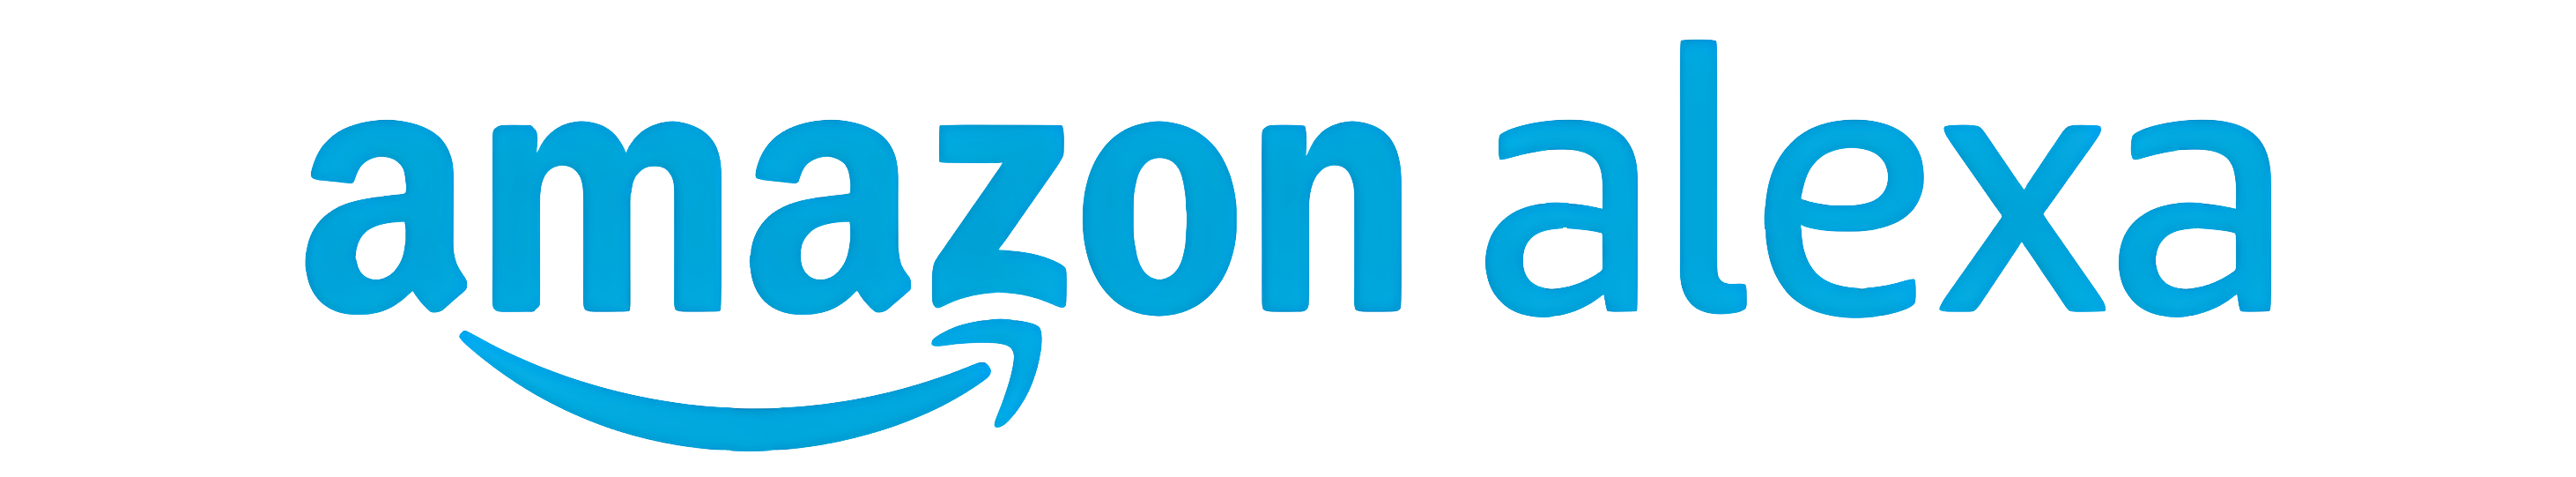

# 1. import Library

In [20]:
# === Базовые библиотеки ===
import pandas as pd                     # работа с таблицами и DataFrame
import numpy as np                      # численные вычисления, массивы
import matplotlib.pyplot as plt         # построение графиков
import matplotlib.cm as cm              # цветовые карты для графиков
import seaborn as sns                   # визуализация (heatmap, стиль графиков)
import re                               # регулярные выражения
import time                             # измерение времени выполнения

# === NLP (Natural Language Processing) ===
import nltk                                      # основной пакет для обработки текста
nltk.download('stopwords', quiet=True)           # стоп-слова
nltk.download('punkt')                           # токенизация
nltk.download('wordnet')                         # словарь WordNet для лемматизации
nltk.download('averaged_perceptron_tagger_eng')  # POS-теггер (части речи)
nltk.download('omw-1.4')                         # мультиязычные словари WordNet

from nltk.corpus import stopwords, wordnet              # 'пустые' слова
from nltk.stem import PorterStemmer, WordNetLemmatizer  # стемминг, лематизация
from nltk import pos_tag                                # определение частей речи

# === Виджеты для UI ===
from ipywidgets import IntProgress, Button, VBox, HBox, Output, Layout
from ipywidgets import HTML as HTMLipy  
from IPython.display import display, HTML

# === Машинное обучение (sklearn) ===
from sklearn.feature_extraction.text import TfidfVectorizer           # TF-IDF для текста
from sklearn.model_selection import train_test_split,cross_val_score  # разбиение и кросс-валидация
from sklearn.pipeline import Pipeline                                 # пайплайн для обработки
from sklearn.compose import ColumnTransformer                         # трансформация разных типов признаков
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler         # кодирование категорий и нормализация чисел

# === Модели классификации ===
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# === Метрики качества ===
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, auc,
    f1_score, recall_score
)

import joblib

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DENIS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DENIS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\DENIS\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\DENIS\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
#  Стиль Кнопок
model_button_style = HTML("""
<style>
.widget-button {
    font-family: 'Unbounded';
    font-size: 10px;
    font-weight: bold;
    color: white;
    background: linear-gradient(190deg, #4b6cb7 0%, #182848 100%);
    border: none;
    border-radius: 8px;
    box-shadow: 0 4px 6px rgba(0,0,0,0.3);
    transition: all 0.2s ease-in-out;
}
.widget-button:hover {
    box-shadow: 0 6px 10px rgba(0,0,0,0.4);
    transform: scale(1.1) translateY(-3px);
}
.widget-button:active {
    box-shadow: inset 0 2px 4px rgba(0,0,0,0.5);
    transform: translateY(2px);
}
</style>
""")
model_button_style

# 2. import Dataset

In [3]:
data_no_engine = pd.read_csv('../dataset/amazon_alexa.tsv', sep='\t')
data_no_engine.date = pd.to_datetime(data_no_engine.date, format='mixed')
data_no_engine = data_no_engine.dropna().reset_index(drop=True).copy()
data_no_engine

,rating,date,variation,verified_reviews,feedback
0,5,2018-07-31,Charcoal Fabric,Love my Echo!,1
1,5,2018-07-31,Charcoal Fabric,Loved it!,1
2,4,2018-07-31,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,2018-07-31,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,2018-07-31,Charcoal Fabric,Music,1
...,...,...,...,...,...
3144,5,2018-07-30,Black Dot,"Perfect for kids, adults and everyone in betwe...",1
3145,5,2018-07-30,Black Dot,"Listening to music, searching locations, check...",1
3146,5,2018-07-30,Black Dot,"I do love these things, i have them running my...",1
3147,5,2018-07-30,White Dot,Only complaint I have is that the sound qualit...,1


# 3. Feature Engineering

In [4]:
data = data_no_engine.copy()

# Тип устройства
group = lambda x: (
    'Echo Dot'      if 'dot'   in x.lower() else
    'Echo Show'     if 'show'  in x.lower() else
    'Echo Spot'     if 'spot'  in x.lower() else
    'Echo Plus'     if 'plus'  in x.lower() else
    'Fire TV Stick' if 'stick' in x.lower() else
    'Echo'
)
data['device_type'] = data['variation'].map(group)

# Длина отзыва
data['review_length'] = data['verified_reviews'].apply(lambda x: len(str(x)))

# Удаляем пустые отзывы (' ')
data = data[data['verified_reviews'] != ' ']

# Удаляем смайлы (длина == 1) и дубликаты
data = (
    data[data['review_length'] != 1]
    .drop_duplicates(subset=['verified_reviews', 'rating', 'date', 'variation'], keep='first')
    .reset_index(drop=True)
)

display(data.head())
print(f'Строк после очистки: {data.shape[0]}')

,rating,date,variation,verified_reviews,feedback,device_type,review_length
0,5,2018-07-31,Charcoal Fabric,Love my Echo!,1,Echo,13
1,5,2018-07-31,Charcoal Fabric,Loved it!,1,Echo,9
2,4,2018-07-31,Walnut Finish,"Sometimes while playing a game, you can answer...",1,Echo,195
3,5,2018-07-31,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1,Echo,172
4,5,2018-07-31,Charcoal Fabric,Music,1,Echo,5


Строк после очистки: 2383


## Функция метрик

In [5]:
def model_results(pipeline, x_train, x_test, y_train, y_test, return_result=False):
    
    """Cross-val,  accuracy."""
    
    cv_scores = cross_val_score(pipeline, x_train, y_train, cv=5, scoring='f1_macro')
    print('-'*55)
    print(f'Cross-Validation F1-macro (5 folds): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
    print('-'*55)
    print(f'Training Accuracy : {pipeline.score(x_train, y_train):.3f}')
    print(f'Testing Accuracy  : {pipeline.score(x_test,  y_test):.3f}\n')

    y_pred_train  = pipeline.predict(x_train)
    y_pred_test   = pipeline.predict(x_test)
    y_proba_train = pipeline.predict_proba(x_train)[:, 1]
    y_proba_test  = pipeline.predict_proba(x_test)[:, 1]
    
    """Classification report, ROC-AUC, PR-AUC, confusion matrices train test."""
    
    for y_true, y_pred, y_proba, split in [
        (y_train, y_pred_train, y_proba_train, 'Train'),
        (y_test,  y_pred_test,  y_proba_test,  'Test')
    ]:
        prec, rec, _ = precision_recall_curve((y_true == 0).astype(int), 1 - y_proba)
        pr_auc = auc(rec, prec)

        print(f'Classification Report {split}:\n')
        print(classification_report(y_true, y_pred, digits=3, target_names=['Negative', 'Positive']))
        print(f'ROC-AUC {split}          : {roc_auc_score(y_true, y_proba):.3f}')
        print(f'PR-AUC (Negative) {split}: {pr_auc:.3f}\n')

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, (y_true, y_pred, split) in zip(axes, [
        (y_train, y_pred_train, 'Train'),
        (y_test,  y_pred_test,  'Test')
    ]):
        sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', ax=ax,
                    xticklabels=['Negative', 'Positive'],
                    yticklabels=['Negative', 'Positive'])
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_title(f'Confusion Matrix — {split}')
    plt.suptitle(f'(Default threshold 0.5)'.strip(), fontsize=13)
    plt.tight_layout()
    plt.show()

    prec_te, rec_te, _ = precision_recall_curve((y_test  == 0).astype(int), 1 - y_proba_test)
    pr_auc_test  = auc(rec_te, prec_te)

    if return_result:
        return y_pred_test, y_proba_test, pr_auc_test

## Функция лучшего порога

In [6]:
def model_best_threshold(pipeline, x_train, x_test, y_train, y_test, return_result=False):
    
    y_pred_train  = pipeline.predict(x_train)
    y_pred_test   = pipeline.predict(x_test)
    y_proba_train = pipeline.predict_proba(x_train)[:, 1]
    y_proba_test  = pipeline.predict_proba(x_test)[:, 1]
    
    """Find best threshold, classification report и confusion matrices для train и test."""
    
    thresholds = np.arange(0.1, 0.9, 0.01)
    f1_scores  = [f1_score(y_test, (y_proba_test >= t).astype(int), pos_label=0) for t in thresholds]
    best_threshold = thresholds[np.argmax(f1_scores)]

    y_pred_best_train = (y_proba_train >= best_threshold).astype(int)
    y_pred_best_test  = (y_proba_test  >= best_threshold).astype(int)

    print(f'{"="*55}')
    print(f'  Default threshold: 0.50   |   Best threshold: {best_threshold:.2f}')
    print(f'{"="*55}')
    print(f'F1 (Negative) for default: {f1_score(y_test, y_pred_test,      pos_label=0):.3f}')
    print(f'F1 (Negative) for best   : {f1_score(y_test, y_pred_best_test, pos_label=0):.3f}\n')

    for y_true, y_pred, split in [
        (y_train, y_pred_best_train, 'Train'),
        (y_test,  y_pred_best_test,  'Test')
    ]:
        print(f'Classification Report {split} (threshold {best_threshold:.2f}):\n')
        print(classification_report(y_true, y_pred, digits=3, target_names=['Negative', 'Positive']))

    # График порога
    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, f1_scores, color='steelblue', linewidth=2)
    plt.axvline(best_threshold, color='red',  linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
    plt.axvline(0.5,            color='gray', linestyle=':',  label='Default threshold = 0.50')
    plt.xlabel('Threshold')
    plt.ylabel('F1 (Negative)')
    plt.title('F1 negative by threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Confusion matrix: порог 0.5 vs лучший
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, (y_pred, label) in zip(axes, [
        (y_pred_test,      'Порог 0.50'),
        (y_pred_best_test, f'Threshold {best_threshold:.2f} (best)')
    ]):
        sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', ax=ax,
                    xticklabels=['Negative', 'Positive'],
                    yticklabels=['Negative', 'Positive'])
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_title(label)
    plt.suptitle(f'Threshold compare'.strip(), fontsize=13)
    plt.tight_layout()
    plt.show()

    if return_result:
        return y_pred_best_test, best_threshold

# 4. Baseline → LogisticRegression (TF-IDF only)

In [7]:
pipeline_base = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=2500)),
    ('model', LogisticRegression(class_weight='balanced', random_state=0, max_iter=1000))
])

X_base = data_no_engine['verified_reviews']
y_base = data_no_engine['feedback']

x_train_b, x_test_b, y_train_b, y_test_b = train_test_split(
    X_base, y_base,
    test_size=0.17,
    stratify=y_base,
    random_state=42
)
print(f'Train: {x_train_b.shape[0]} | Test: {x_test_b.shape[0]}')

Train: 2613 | Test: 536


In [8]:
# Обучаем и получаем вероятности
pipeline_base.fit(x_train_b, y_train_b)

,steps,"[('tfidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


-------------------------------------------------------
Cross-Validation F1-macro (5 folds): 0.758 ± 0.008
-------------------------------------------------------
Training Accuracy : 0.940
Testing Accuracy  : 0.903

Classification Report Train:

              precision    recall  f1-score   support

    Negative      0.583     0.915     0.712       212
    Positive      0.992     0.942     0.966      2401

    accuracy                          0.940      2613
   macro avg      0.787     0.929     0.839      2613
weighted avg      0.959     0.940     0.946      2613

ROC-AUC Train          : 0.992
PR-AUC (Negative) Train: 0.935

Classification Report Test:

              precision    recall  f1-score   support

    Negative      0.449     0.795     0.574        44
    Positive      0.980     0.913     0.945       492

    accuracy                          0.903       536
   macro avg      0.715     0.854     0.760       536
weighted avg      0.937     0.903     0.915       536

ROC-AUC 

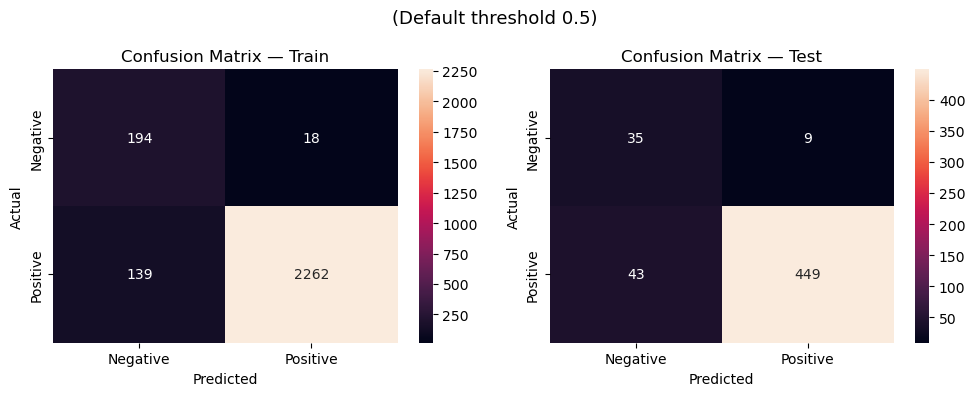

In [9]:
model_results(pipeline_base, x_train_b, x_test_b, y_train_b, y_test_b)

  Default threshold: 0.50   |   Best threshold: 0.35
F1 (Negative) for default: 0.574
F1 (Negative) for best   : 0.651

Classification Report Train (threshold 0.35):

              precision    recall  f1-score   support

    Negative      0.884     0.901     0.893       212
    Positive      0.991     0.990     0.990      2401

    accuracy                          0.982      2613
   macro avg      0.938     0.945     0.941      2613
weighted avg      0.983     0.982     0.982      2613

Classification Report Test (threshold 0.35):

              precision    recall  f1-score   support

    Negative      0.667     0.636     0.651        44
    Positive      0.968     0.972     0.970       492

    accuracy                          0.944       536
   macro avg      0.817     0.804     0.810       536
weighted avg      0.943     0.944     0.943       536



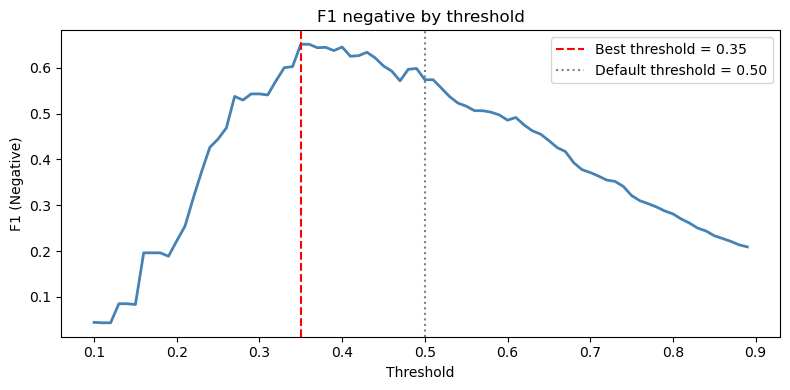

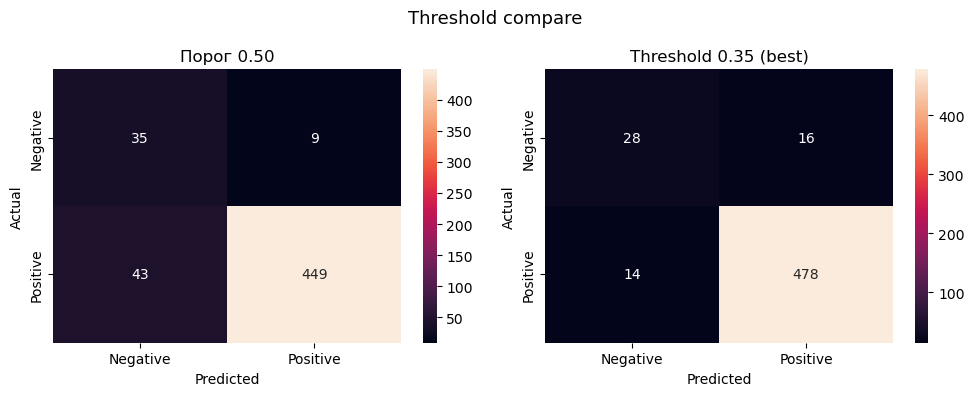

In [10]:
model_best_threshold(pipeline_base, x_train_b, x_test_b, y_train_b, y_test_b)

# 5. Main pipeline

## Подготовка текста

In [11]:
# Стемминг, обрезка слова до основы
ps = PorterStemmer()
# Лематизация, приведение к нормальной форме
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

negation_words = {
    'no','nor','not',"don't","didn't","doesn't","won't","isn't","aren't",
    "wasn't","weren't","can't","cannot","couldn't","shouldn't","wouldn't",
    "haven't","hasn't","hadn't","mustn't","mightn't","shan't",
    "ain't","never","nothing","nowhere","neither","without",
    "nobody","none"
}
stop_words_neg = stop_words - negation_words

# POS → WordNet, части речи
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

# Стемминг
def preprocess_stem(text):
    text = re.sub('[^a-zA-Z]', ' ', str(text)).lower()
    words = [ps.stem(w) for w in text.split() if w not in stop_words_neg]
    return ' '.join(words)

# Лемматизация
def preprocess_lemma(text):
    text = re.sub('[^a-zA-Z]', ' ', str(text)).lower()
    words = [w for w in text.split() if w not in stop_words_neg]
    tagged = pos_tag(words, lang='eng')
    lemmas = [lemmatizer.lemmatize(w, get_wordnet_pos(tag)) for w, tag in tagged]
    return ' '.join(lemmas)

# Подготовка признаков
data['reviews_stemmed'] = data['verified_reviews'].apply(preprocess_stem)
data['reviews_lemmatized'] = data['verified_reviews'].apply(preprocess_lemma)

### Датасет для моделей

In [12]:
# Датасет для моделей
data_to_model = data.copy()

In [13]:
# Баланс классов: усиливаем минорный (негативный) класс
neg_count = (data['feedback'] == 0).sum()
pos_count = (data['feedback'] == 1).sum()
scale_weight = pos_count / neg_count
print(f'Негативных: {neg_count} | Позитивных: {pos_count}')
print(f'scale_pos_weight = {scale_weight:.2f}')

Негативных: 205 | Позитивных: 2178
scale_pos_weight = 10.62


## Определяем модели и параметры

In [14]:
# Linear SVC с вероятностями через калибровку
linear_svc = CalibratedClassifierCV(
    estimator=LinearSVC(
        penalty='l2',
        loss='squared_hinge',
        C=0.8,
        class_weight='balanced',
        max_iter=2000,
        dual=False,
        random_state=0
    ),
    cv=5
)

# Logistic Regression
log_reg = LogisticRegression(class_weight='balanced', C=0.5, max_iter=1000)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    criterion='gini',
    class_weight='balanced',
    random_state=0
)

# Gradient Boosting
gboost = GradientBoostingClassifier(
    n_estimators=300,    
    learning_rate=0.05,  
    max_depth=4,         
    min_samples_split=10,
    min_samples_leaf=4,  
    max_features='sqrt', 
    subsample=0.8,       
    random_state=0
)

# XGBoost
xgb = XGBClassifier()

# Naive Bayes
nb = MultinomialNB(
    alpha=0.1,        # сглаживание
    fit_prior=True    # учитывать дисбаланс классов
)

# KNN
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')

# Linear SVC с калибровкой (как у тебя)
linear_svc = CalibratedClassifierCV(
    estimator=LinearSVC(
        penalty='l2',
        loss='squared_hinge',
        C=0.8,
        class_weight='balanced',
        max_iter=2000,
        dual=False,
        random_state=0
    ),
    cv=5
)

# SuperLearner (Stacking)
super_learner = StackingClassifier(
    estimators=[
        ('LogisticReg', log_reg),
        ('RF', rf),
        ('GBoost', gboost),
        #('XGBoost', xgb),
        #('NB', nb),
        #('KNN', knn),
        ('LinearSVC', linear_svc)
    ],
    final_estimator=log_reg,
    cv=5,
    passthrough=False,
    n_jobs=-1
)


models = {
    'Logistic Regression': log_reg,
    'Random Forest': rf,
    'Gradient Boosting': gboost,
    'XGBoost': xgb,
    'Naive Bayes': nb,
    'KNN': knn,
    'Linear SVC': linear_svc,
    'SuperLearner': super_learner
}

# 6. Pipe function

In [15]:
def run_model(model, data_to_model):
    
    """
    Parameters:
    - model        : sklearn-совместимая модель
    - data_to_model: подготовленный DataFrame (data с feature engineering)
    """
    
    total_start = time.time()
    display(HTML('<img src="alan-formula.gif" width="500">'))
    prgBar = IntProgress(min=0, max=4)
    display(prgBar)
    prgBar.value += 1

    # 1. Копия + сплит
    data = data_to_model.copy()
    display(data.head())
    display(data.shape)
    
    X = data.drop(columns=['feedback', 'date', 'rating', 'verified_reviews', 'variation'], errors='ignore')
    y = data['feedback']

    x_train, x_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.17, random_state=0
    )
    prgBar.value += 1

    # 2. Pipeline
    preprocessor = ColumnTransformer(transformers=[
        
        ('tfidf_stem',  TfidfVectorizer(norm='l2', min_df=2, max_df=0.6, ngram_range=(1, 2), max_features=15000, sublinear_tf=True), 'reviews_stemmed'),
        
        ('tfidf_lemma', TfidfVectorizer(ngram_range=(1, 3), max_df=0.6, max_features=15000),                       'reviews_lemmatized'),
        
        ('cat',         OneHotEncoder(handle_unknown='ignore', sparse_output=False),                  ['device_type']),
        
        ('num',         MinMaxScaler(),                                                               ['review_length'])
    
    ])
    
    pipeline = Pipeline([('preprocessing', preprocessor), ('model', model)])
    display(pipeline)
    
    prgBar.value += 1

    pipeline.fit(x_train, y_train)

    y_pred_test, y_proba_test, pr_auc_test = model_results(pipeline, x_train, x_test, y_train, y_test, return_result=True)
    
    y_pred_best_test, best_threshold = model_best_threshold(pipeline, x_train, x_test, y_train, y_test, return_result=True)
    
    # 10. Сохраняем в results_df
    cl_05   = classification_report(y_test, y_pred_test,      output_dict=True, target_names=['Negative', 'Positive'])
    cl_best = classification_report(y_test, y_pred_best_test, output_dict=True, target_names=['Negative', 'Positive'])

    results_df.loc[len(results_df)] = [
        model.__class__.__name__,
        round(pipeline.score(x_test, y_test),       3),
        round(roc_auc_score(y_test, y_proba_test),  3),
        round(pr_auc_test,                          3),
        round(cl_05['Negative']['precision'],       3),
        round(cl_05['Negative']['recall'],          3),
        round(cl_05['Negative']['f1-score'],        3),
        round(best_threshold,                       2),
        round(cl_best['Negative']['precision'],     3),
        round(cl_best['Negative']['recall'],        3),
        round(cl_best['Negative']['f1-score'],      3),
    ]
    prgBar.value += 1
    
    last_model_bundle['pipeline']       = pipeline
    last_model_bundle['best_threshold'] = best_threshold
    last_model_bundle['model_name']     = model.__class__.__name__

    print(f'\nОбщее время выполнения: {time.time() - total_start:.2f} сек.')

In [16]:
# DataFrame для метрик
results_df = pd.DataFrame(columns=[
    'Model',
    'Test Accuracy',
    'Test ROC-AUC',
    'Test PR-AUC Negative',
    # Порог 0.5
    'Test Negative - precision',
    'Test Negative - recall',
    'Test Negative - f1-score',
    # Лучший порог
    'Best Threshold',
    'Best Negative - precision',
    'Best Negative - recall',
    'Best Negative - f1-score'
])

In [17]:

last_model_bundle = {
    'pipeline':       None,
    'best_threshold': None,
    'model_name':     None
}

# 7. UI function

In [31]:
def run_model_button(name, model):
    """Запуск модели."""
    with output:
        output.clear_output()
        display(HTML(f"<div style='font-size:24px;'>🔄 Модель: <b>{name}</b></div>"))
        run_model(model, data_to_model)

def show_result():
    """График сравнения всех запущенных моделей."""
    with output:
        output.clear_output()
        if results_df.empty:
            print('Нет данных. Запустите хотя бы одну модель.')
            return

        results = results_df.set_index('Model')
        colors  = cm.YlGn(np.linspace(0.3, 1, len(results)))

        fig, axs = plt.subplots(3, 2, figsize=(16, 12))
        fig.suptitle('Сравнение метрик моделей', fontsize=16)

        metrics = [
            ('Test Accuracy',             axs[0, 0]),
            ('Test ROC-AUC',              axs[1, 0]),
            ('Test PR-AUC Negative',      axs[2, 0]),
            ('Test Negative - precision', axs[0, 1]),
            ('Test Negative - recall',    axs[1, 1]),
            ('Test Negative - f1-score',  axs[2, 1]),
        ]

        for metric, ax in metrics:
            results[metric].sort_values(ascending=True).plot(
                kind='barh', ax=ax, title=metric, color=colors
            )
            for p in ax.patches:
                ax.text(
                    p.get_width(),
                    p.get_y() + p.get_height() / 2,
                    f'{p.get_width():.3f}',
                    ha='left', va='center', fontsize=9
                )

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        display(results_df)


def clear():
    """Очистка результатов."""
    global results_df
    results_df = pd.DataFrame(columns=results_df.columns)
    with output:
        output.clear_output()
        print('Результаты очищены.')

def save_model():
    with output:
        output.clear_output()
        if last_model_bundle['pipeline'] is None:
            print('Нет данных. Запустите хотя бы одну модель.')
            return
        joblib.dump(last_model_bundle, 'model.pkl')
        print('✅ Сохранение модели:') 
        print(f'Модель: {last_model_bundle['model_name']} с порогом {last_model_bundle['best_threshold']:.2f}')

# 8. Results and start UI

In [19]:
# Вывод для отображения результатов
output = Output()
buttons = []
# Кнопки для каждой модели
for name, model in models.items():
    btn = Button(description=name,
                 layout=Layout(width='30%',
                               height='60px'),
                 style={'font_size': '20px'})
    
    btn.on_click(lambda b, n=name, m=model: run_model_button(n, m))
    buttons.append(btn)

result_button = Button(description='Show Metrics to Compare',
                       layout=Layout(width='25%',
                                     height='60px'),
                       style={'font_size': '14px',
                             'text_color': 'black'})

result_button.on_click(lambda b: show_result())
buttons.append(result_button)

clear_button = Button(
    description='🧹 Clear all',
    layout=Layout(width='25%',height='60px'),
    style={'button_color': '#c8e6c9','font_size': '14px', 'text_color': 'black'}
)
clear_button.on_click(lambda b: clear())
buttons.append(clear_button)

save_button = Button(
    description='💾 Save model',
    layout=Layout(width='25%',height='60px'),
    style={'button_color': '#c8e6c9','font_size': '14px', 'text_color': 'black'}
)
save_button.on_click(lambda b: save_model())
buttons.append(save_button)

# Отображение
vbox = VBox(buttons + [output],
            layout=Layout(
                align_items='center'
            ))

display(vbox)